In [ ]:
import pandas as pd

files = [
'data/aiana94_polynews/lithuanian_word_counts.tsv',
'data/ccll2_vs_war_in_UA/lithuanian_word_counts.tsv',
'data/common_voice_17/lithuanian_word_counts.tsv',
'data/community-datasets_tapaco/lithuanian_word_counts.tsv',
'data/Corpus_of_Discourse_on_Crime-LT/lithuanian_word_counts.tsv',
'data/DIGIRES_COVID19_LT/lithuanian_word_counts.tsv',
# 'data/DML6_vs_JCL/lithuanian_word_counts.tsv',
# 'data/EN-LT-FR_Parallel-corpus/lithuanian_word_counts.tsv',
'data/EN-LT_Comparable_Vaccination_corpus/lithuanian_word_counts.tsv',
'data/EN-LT_Parallel_CS_Corpus-v2/lithuanian_word_counts.tsv',
# 'data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv', +
# 'data/European Parliament Proceedings Parallel Corpus 1996-2011/lithuanian_word_counts.tsv',
# 'data/Fizinių_asmenų_bankrotas/lithuanian_word_counts.tsv', +
# 'data/grams/lithuanian_word_counts.tsv',
# 'data/HuggingFaceFW_finepdfs/lithuanian_word_counts.tsv',
# 'data/ispell-lt/lithuanian_word_counts.tsv', + 
# 'data/KLASIUS/lithuanian_word_counts.tsv',
# 'data/Lietuviu-kalbos-rasybos-tikrintuvai-bei-Hunspell-zodynai-gramatika/lithuanian_word_counts.tsv',
# 'data/Lithuanian Coreference Corpus/lithuanian_word_counts.tsv',
# 'data/Lithuanian-Hunspell-dictionary/lithuanian_word_counts.tsv', +
# 'data/Lithuanian-wordlist/lithuanian_word_counts.tsv',
# 'data/lithuanian-words-txt/lithuanian_word_counts.tsv',
'data/Lithuanian_Parliament_Corpus/lithuanian_word_counts.tsv',
'data/MATAS-v1.0/lithuanian_word_counts.tsv',
'data/mteb_biblenlp-corpus-mmteb/lithuanian_word_counts.tsv',
'data/PaDaS-Lab_webfaq/lithuanian_word_counts.tsv',
'data/qanastek_EMEA-V3/lithuanian_word_counts.tsv',
'data/scoris_en-lt-merged-data/lithuanian_word_counts.tsv',
# 'data/SkolintuZodynas/lithuanian_word_counts.tsv',
# 'data/vietovardziu_zodynas/lithuanian_word_counts.tsv',
'data/wikimediawikipedia/lithuanian_word_counts.tsv'
]

always_include = [
    'data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv',
    'data/Fizinių_asmenų_bankrotas/lithuanian_word_counts.tsv',
    'data/ispell-lt/lithuanian_word_counts.tsv',
    'data/Lithuanian-Hunspell-dictionary/lithuanian_word_counts.tsv',
]

dfs = []
for file in files:
    try:
        df = pd.read_csv(file, sep='\t', on_bad_lines='skip')
        # Rename columns to 'text' and 'count'
        if len(df.columns) >= 2:
            df = df.rename(columns={df.columns[0]: 'text', df.columns[1]: 'count'})
            dfs.append(df[['text', 'count']])
        else:
            print(f"Skipping {file}: unexpected number of columns")
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all dataframes
combined_df = pd.concat(dfs, ignore_index=True)

# Group by 'text' and sum 'count'
combined_df = combined_df.groupby('text', as_index=False)['count'].sum()

# Sort by count descending
combined_df = combined_df.sort_values('count', ascending=False)

# Define Lithuanian letters
lithuanian_letters = set('aąbcčdeęėfghįiyjklmnoprsštuųūvzžAĄBCČDEĘĖFGHĮIYJKLMNOPRSŠTUŲŪVZŽ')

# Filter to keep only texts with Lithuanian letters only
combined_df = combined_df[combined_df['text'].apply(lambda x: all(c in lithuanian_letters for c in str(x)))]

# Display the combined dataframe
print("Combined word counts (Lithuanian letters only):")
print(combined_df.head(20))  # Show top 20

# Optionally save to a file
combined_df.to_csv('combined_word_counts.tsv', sep='\t', index=False)

Error reading data/EN-LT-FR_Parallel-corpus/lithuanian_word_counts.tsv: [Errno 2] No such file or directory: 'data/EN-LT-FR_Parallel-corpus/lithuanian_word_counts.tsv'
Error reading data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv: [Errno 2] No such file or directory: 'data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv'
Combined word counts (Lithuanian letters only):
         text    count
1044302    ir  3566829
1481411     m  1308807
1166577   kad  1249190
3113770   yra  1022216
3167775     į   870517
2670324    su   749478
1059474    iš   694141
2778970   tai   668368
490171   buvo   656271
1170549  kaip   527860
691028    dėl   474391
1919898   nuo   446203
244795     ar   434735
2780461  taip   423627
1955863     o   376443
212233   apie   347411
2503348  savo   338936
332189     aš   310304
1558937   mes   307611
564015      d   292790


In [2]:
import pandas as pd

# Load the combined word counts
combined_df = pd.read_csv('combined_word_counts.tsv', sep='\t')

n = 9

# Filter for n-letter words
eight_letter_words = combined_df[combined_df['text'].str.len() == n]['text']

# Take only top 100000 words
eight_letter_words = eight_letter_words.head(100000)

# Save to n_letters.txt
eight_letter_words.to_csv(f'{n}_letters.txt', index=False, header=False)

print(f"Saved {len(eight_letter_words)} {n}-letter words to {n}_letters.txt")
print(eight_letter_words.head(10))

Saved 100000 9-letter words to 9_letters.txt
78     valstybės
80     šaltiniai
99     komisijos
170    klausimas
180    valstybių
206    komitetas
209    projektas
215    lietuvoje
236    bendrovės
264    politikos
Name: text, dtype: object


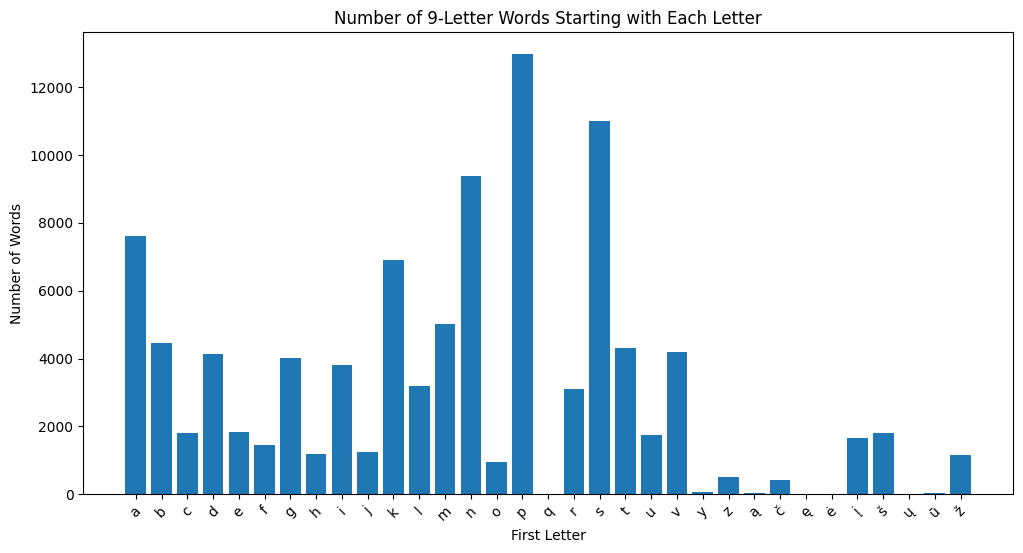

In [3]:
import matplotlib.pyplot as plt

# Read the file
with open(f'{n}_letters.txt', 'r', encoding='utf-8') as f:
    words = [line.strip() for line in f if line.strip()]

# Define the order of letters
letter_order = "abcdefghijklmnopqrstuvyząčęėįšųūž"

# Count words starting with each letter
counts = {letter: 0 for letter in letter_order}
for word in words:
    if word:
        first_letter = word[0].lower()
        if first_letter in counts:
            counts[first_letter] += 1

# Prepare data for plotting
letters = list(letter_order)
values = [counts[letter] for letter in letters]

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(letters, values)
plt.xlabel('First Letter')
plt.ylabel('Number of Words')
plt.title(f'Number of {n}-Letter Words Starting with Each Letter')
plt.xticks(rotation=45)
plt.show()

In [4]:
from collections import defaultdict

# Assuming letters and values are available from previous cells
# letters: list of letters
# values: list of counts corresponding to letters

# Pair letters with their values and sort by value descending
letter_value_pairs = sorted(zip(letters, values), key=lambda x: x[1], reverse=True)

# Initialize 4 groups as lists, and their current sums
groups = [[] for _ in range(4)]
group_sums = [0] * 4

# Greedily assign each letter to the group with the smallest current sum
for letter, value in letter_value_pairs:
    min_sum_index = group_sums.index(min(group_sums))
    groups[min_sum_index].append(letter)
    group_sums[min_sum_index] += value

# Print the groups and their sums for verification
for i, group in enumerate(groups):
    print(f"Group {i+1}: {group}, Sum: {group_sums[i]}")

# Now, if you want to split the words list based on first letter into these groups
word_groups = [[] for _ in range(4)]
for word in words:
    first_letter = word[0].lower()
    for i, group in enumerate(groups):
        if first_letter in group:
            word_groups[i].append(word)
            break

# word_groups now contains the split words
# For example, print lengths
for i, wg in enumerate(word_groups):
    print(f"Word group {i+1} length: {len(wg)}")

Group 1: ['p', 't', 'i', 'c', 'f', 'o'], Sum: 25264
Group 2: ['s', 'b', 'g', 'e', 'š', 'j', 'z'], Sum: 24887
Group 3: ['n', 'm', 'v', 'l', 'į', 'h', 'č'], Sum: 25037
Group 4: ['a', 'k', 'd', 'r', 'u', 'ž', 'y', 'ū', 'ą', 'ė', 'q', 'ę', 'ų'], Sum: 24812
Word group 1 length: 25264
Word group 2 length: 24887
Word group 3 length: 25037
Word group 4 length: 24812


In [5]:
# Print all group letters in one string
all_letters = ''.join(sum(groups, []))
print(all_letters)

pticfosbgešjznmvlįhčakdružyūąėqęų


In [6]:
count = 0
for letter in all_letters:
    print(f"{count}={letter}, ", end="")
    count += 1

0=p, 1=t, 2=i, 3=c, 4=f, 5=o, 6=s, 7=b, 8=g, 9=e, 10=š, 11=j, 12=z, 13=n, 14=m, 15=v, 16=l, 17=į, 18=h, 19=č, 20=a, 21=k, 22=d, 23=r, 24=u, 25=ž, 26=y, 27=ū, 28=ą, 29=ė, 30=q, 31=ę, 32=ų, 